# Ex 6 — Classification Techniques

**Dataset:** Music Genre Classification  
**Target:** Class (11 genres, 0–10)  
**Reg No:** URK24CS1021

In [1]:
print("URK24CS1021")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
SEED = 1021

df = pd.read_csv("music_genre.csv")
df.head()

URK24CS1021


,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Li...,60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,6
3,Deno,Lingo (feat. J.I...,66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,5
4,Red Hot Chili Pe...,Nobody Weird Lik...,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,10


### How balanced are the classes?

In [2]:
print("URK24CS1021")

df["Class"].value_counts().sort_index()

URK24CS1021


Class
0      625
1     1373
2     1272
3      402
4      387
5     1447
6     2587
7      576
8     1854
9     2524
10    4949
Name: count, dtype: int64

In [3]:
print("URK24CS1021")

# the baseline any classifier has to beat: always guess the biggest class
df["Class"].value_counts(normalize=True).max()

URK24CS1021


np.float64(0.27500555679039784)

### Two things wrong with this file before anything can be fitted

In [4]:
print("URK24CS1021")

# the column is literally named "duration_in min/ms" - and it means it
dur = df["duration_in min/ms"]
(dur < 100).sum(), (dur >= 100).sum()

URK24CS1021


(np.int64(2580), np.int64(15416))

In [5]:
print("URK24CS1021")

df["duration_min"] = np.where(dur < 100, dur, dur / 60000)
df["duration_min"].describe()

URK24CS1021


count    17996.000000
mean         3.930388
std          1.427917
min          0.388667
25%          3.127496
50%          3.666667
75%          4.384704
max         29.886000
Name: duration_min, dtype: float64

In [6]:
print("URK24CS1021")

df.isnull().sum()[df.isnull().sum() > 0]

URK24CS1021


Popularity           428
key                 2014
instrumentalness    4377
dtype: int64

In [7]:
print("URK24CS1021")

for col in ["Popularity", "key", "instrumentalness"]:
    df[col] = df[col].fillna(df[col].median())
df.isnull().sum().sum()

URK24CS1021


np.int64(0)

### Features, and why the run is sampled

In [8]:
print("URK24CS1021")

# names are unique per row, so nothing to generalise from
X = df.drop(columns=["Artist Name", "Track Name", "Class",
                     "duration_in min/ms", "duration_min"])
X["duration_min"] = df["duration_min"]
y = df["Class"]

# SVM is quadratic in rows, so every model sees the same 5000-row sample
idx = df.sample(n=5000, random_state=SEED).index
X, y = X.loc[idx], y.loc[idx]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X.shape

URK24CS1021


(5000, 14)

### Five classifiers, same split, same scoring

In [9]:
print("URK24CS1021")

results = []

def score(name, model):
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results.append({"Technique": name, "Train Accuracy": train_acc,
                    "Test Accuracy": test_acc})
    return model

# KNN and SVM measure distance, so they get a scaler; the tree does not care
knn = score("KNN", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)))
results[-1]

URK24CS1021


{'Technique': 'KNN', 'Train Accuracy': 0.57425, 'Test Accuracy': 0.362}

In [10]:
print("URK24CS1021")

tree = score("Decision Tree", DecisionTreeClassifier(max_depth=10, random_state=SEED))
results[-1]

URK24CS1021


{'Technique': 'Decision Tree', 'Train Accuracy': 0.642, 'Test Accuracy': 0.398}

In [11]:
print("URK24CS1021")

forest = score("Random Forest", RandomForestClassifier(n_estimators=200, random_state=SEED))
results[-1]

URK24CS1021


{'Technique': 'Random Forest', 'Train Accuracy': 0.97675, 'Test Accuracy': 0.487}

In [12]:
print("URK24CS1021")

logreg = score("Logistic Regression",
               make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=2000, random_state=SEED)))
results[-1]

URK24CS1021


{'Technique': 'Logistic Regression', 'Train Accuracy': 0.4525, 'Test Accuracy': 0.462}

In [13]:
print("URK24CS1021")

svm = score("SVM", make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=SEED)))
results[-1]

URK24CS1021


{'Technique': 'SVM', 'Train Accuracy': 0.54225, 'Test Accuracy': 0.48}

### Report and confusion matrix for the best model

In [14]:
print("URK24CS1021")

pred = forest.predict(X_test)
print(classification_report(y_test, pred, zero_division=0))

URK24CS1021
              precision    recall  f1-score   support

           0       0.39      0.19      0.26        36
           1       0.15      0.04      0.06        77
           2       0.39      0.24      0.30        71
           3       0.78      0.35      0.48        20
           4       0.00      0.00      0.00        21
           5       0.80      0.67      0.73        83
           6       0.38      0.31      0.34       144
           7       0.72      0.79      0.75        29
           8       0.61      0.61      0.61       102
           9       0.45      0.53      0.49       141
          10       0.46      0.70      0.55       276

    accuracy                           0.49      1000
   macro avg       0.47      0.40      0.42      1000
weighted avg       0.46      0.49      0.46      1000



URK24CS1021


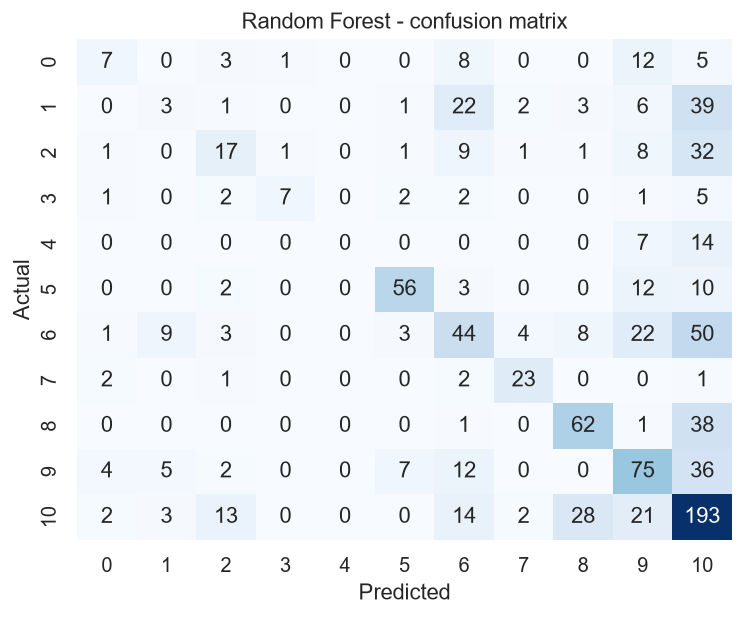

In [15]:
print("URK24CS1021")

sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Random Forest - confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### The comparison — and where the overfitting shows

In [16]:
print("URK24CS1021")

table = pd.DataFrame(results).set_index("Technique").round(4)
table["Gap"] = (table["Train Accuracy"] - table["Test Accuracy"]).round(4)
table

URK24CS1021


,Train Accuracy,Test Accuracy,Gap
Technique,,,
KNN,0.5742,0.362,0.2122
Decision Tree,0.6420,0.398,0.2440
Random Forest,0.9768,0.487,0.4898
Logistic Regression,0.4525,0.462,-0.0095
SVM,0.5422,0.480,0.0622


URK24CS1021


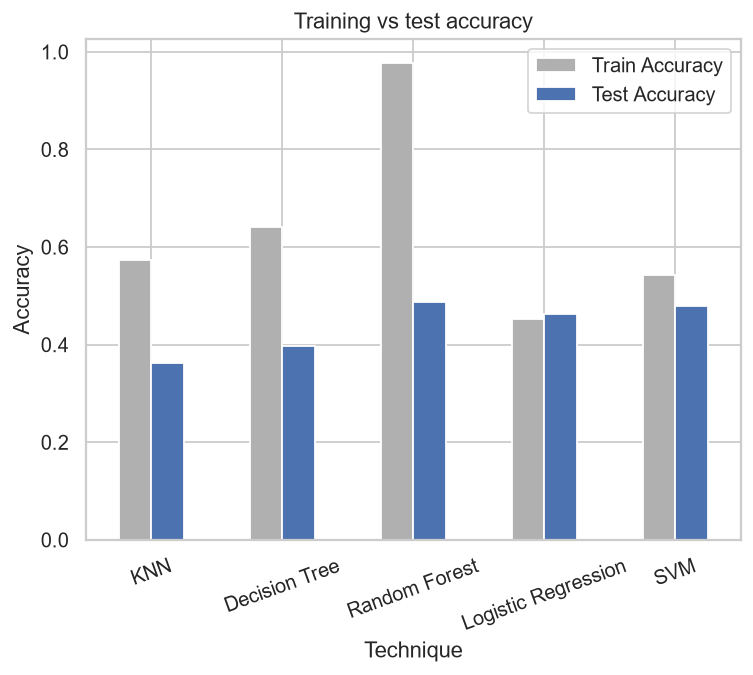

In [17]:
print("URK24CS1021")

table[["Train Accuracy", "Test Accuracy"]].plot(kind="bar", rot=20,
                                                color=["#B0B0B0", "#4C72B0"])
plt.ylabel("Accuracy")
plt.title("Training vs test accuracy")
plt.show()